# Select Sample Based on Indices, Resize, Combine, Create Label, and Save

In [1]:
import os
import numpy as np
import cv2 # Read image; Resize image function
from tqdm import tqdm # Instantly make your loops show a smart progress meter - just wrap any iterable with tqdm(iterable)
import pickle # Save variables

In [3]:
# Loading indices array
data = np.load('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/indices.npz')
train_idx_crack_arr = data['array1']
val_idx_crack_arr = data['array2']
test_idx_crack_arr = data['array3']
train_idx_good_arr = data['array4']
val_idx_good_arr = data['array5']
test_idx_good_arr = data['array6']
train_idx_cf_arr = data['array7']
val_idx_cf_arr = data['array8']
test_idx_cf_arr = data['array9']

# Convert to list
train_idx_crack = train_idx_crack_arr.tolist()
val_idx_crack = val_idx_crack_arr.tolist()
test_idx_crack = test_idx_crack_arr.tolist()
train_idx_good = train_idx_good_arr.tolist()
val_idx_good = val_idx_good_arr.tolist()
test_idx_good = test_idx_good_arr.tolist()
train_idx_cf = train_idx_cf_arr.tolist()
val_idx_cf = val_idx_cf_arr.tolist()
test_idx_cf = test_idx_cf_arr.tolist()

print('Crack - train:', len(train_idx_crack), ', validation:', len(val_idx_crack), ', test:', len(test_idx_crack))
print('Good - train:', len(train_idx_good), ', validation:', len(val_idx_good), ', test:', len(test_idx_good))
print('CF - train:', len(train_idx_cf), ', validation:', len(val_idx_cf), ', test:', len(test_idx_cf))

Crack - train: 715 , validation: 90 , test: 89
Good - train: 1618 , validation: 202 , test: 202
CF - train: 345 , validation: 43 , test: 43


In [4]:
# Parameters
IMG_SIZE = 224
dir_crack = 'C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/Crack_rmbg_crop_rdrs'
dir_good = 'C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/Good_rmbg_crop_rdrs'
dir_cf = 'C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/CF_rmbg_crop_rdrs'

### Train

In [5]:
# Retrive all the training images path
train_img_paths = []
# Crack image paths collecting
for i in train_idx_crack:
        img_path = dir_crack + '/' + str(i).rjust(4, '0') + '_p.PNG'
        train_img_paths.append(img_path)
# Good image paths collecting
for j in train_idx_good:
        img_path = dir_good + '/' + str(j).rjust(4, '0') + '_p.PNG'
        train_img_paths.append(img_path)
# CF image paths collecting
for k in train_idx_cf:
    img_path = dir_cf + '/' + str(k).rjust(4, '0') + '_p.PNG'
    train_img_paths.append(img_path)

# Read images, resize, form a numpy array and transpose dimension location
temp_lst = []
for m in tqdm(train_img_paths):
    img = cv2.imread(m)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation = cv2.INTER_AREA)
    temp_lst.append(img)
X_train = np.stack(temp_lst, axis = 3)
X_train = np.transpose(X_train, (3, 2, 0, 1)) # Result dimension: # of samples, color channel, height/width
y_train = [1] * len(train_idx_crack) + [0] * len(train_idx_good) + [2] * len(train_idx_cf)  # Added CF class
# y_train = [1] * len(train_idx_crack) + [0] * len(train_idx_good)
y_train = np.ravel(y_train)  # convert y to a 1-d numpy array, or a python list
print('X_train:', X_train.shape, 'y_train:', y_train.shape)

100%|██████████████████████████████████████████████████████████████████████████████| 2678/2678 [00:29<00:00, 91.25it/s]


X_train: (2678, 3, 224, 224) y_train: (2678,)


### Validation

In [6]:
# Retrive all the Validation images path
val_img_paths = []
# Crack image paths collecting
for i in val_idx_crack:
        img_path = dir_crack + '/' + str(i).rjust(4, '0') + '_p.PNG'
        val_img_paths.append(img_path)
# Good image paths collecting
for j in val_idx_good:
        img_path = dir_good + '/' + str(j).rjust(4, '0') + '_p.PNG'
        val_img_paths.append(img_path)
# CC image paths collecting
for k in val_idx_cf:
    img_path = dir_cf + '/' + str(k).rjust(4, '0') + '_p.PNG'
    val_img_paths.append(img_path)

# Read images, resize, form a numpy array and transpose dimension location
temp_lst = []
for m in tqdm(val_img_paths):
    img = cv2.imread(m)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation = cv2.INTER_AREA)
    temp_lst.append(img)
X_val = np.stack(temp_lst, axis = 3)
X_val = np.transpose(X_val, (3, 2, 0, 1)) # Result dimension: # of samples, color channel, height/width
y_val = [1] * len(val_idx_crack) + [0] * len(val_idx_good) + [2] * len(val_idx_cf)  # Added CF class
# y_val = [1] * len(val_idx_crack) + [0] * len(val_idx_good)
y_val = np.ravel(y_val)  # convert y to a 1-d numpy array, or a python list
print('X_val:', X_val.shape, 'y_val:', y_val.shape)

100%|████████████████████████████████████████████████████████████████████████████████| 335/335 [00:03<00:00, 91.23it/s]


X_val: (335, 3, 224, 224) y_val: (335,)


### Test

In [7]:
# Retrive all the testing images path
test_img_paths = []
# Crack image paths collecting
for i in test_idx_crack:
        img_path = dir_crack + '/' + str(i).rjust(4, '0') + '_p.PNG'
        test_img_paths.append(img_path)
# Good image paths collecting
for j in test_idx_good:
        img_path = dir_good + '/' + str(j).rjust(4, '0') + '_p.PNG'
        test_img_paths.append(img_path)
# CF image paths collecting
for k in test_idx_cf:
    img_path = dir_cf + '/' + str(k).rjust(4, '0') + '_p.PNG'
    test_img_paths.append(img_path)

# Read images, resize, form a numpy array and transpose dimension location
temp_lst = []
for m in tqdm(test_img_paths):
    img = cv2.imread(m)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation = cv2.INTER_AREA)
    temp_lst.append(img)
X_test = np.stack(temp_lst, axis = 3)
X_test = np.transpose(X_test, (3, 2, 0, 1)) # Result dimension: # of samples, color channel, height/width
y_test = [1] * len(test_idx_crack) + [0] * len(test_idx_good) + [2] * len(test_idx_cf)  # Added CF class
# y_test = [1] * len(test_idx_crack) + [0] * len(test_idx_good)
y_test = np.ravel(y_test)  # convert y to a 1-d numpy array, or a python list
print('X_test:', X_test.shape, 'y_test:', y_test.shape)

100%|████████████████████████████████████████████████████████████████████████████████| 334/334 [00:03<00:00, 90.26it/s]

X_test: (334, 3, 224, 224) y_test: (334,)


### Check data structure

In [11]:
# # Check the shape of training and testing datasets
# print('X_train:', X_train.shape, 'X_val:', X_val.shape, 'X_test:', X_test.shape,
#       'y_train:', y_train.shape, 'y_val:', y_val.shape, 'y_test:', y_test.shape)

# # Check the positive rate in the training set
# print('Positive rate in the training set:', sum(y_train)/len(y_train))

# # Check the positive rate in the validation set
# print('Positive rate in the validation set:', sum(y_val)/len(y_val))

# # Check the positive rate in the test set
# print('Positive rate in the test set:', sum(y_test)/len(y_test))

In [8]:
# Check the shape of training and testing datasets
print('X_train:', X_train.shape, 'X_val:', X_val.shape, 'X_test:', X_test.shape)
print('y_train:', y_train.shape, 'y_val:', y_val.shape, 'y_test:', y_test.shape)

# Count occurrences of each class in training set
unique, counts = np.unique(y_train, return_counts=True)
train_class_distribution = dict(zip(unique, counts))

# Count occurrences of each class in validation set
unique, counts = np.unique(y_val, return_counts=True)
val_class_distribution = dict(zip(unique, counts))

# Count occurrences of each class in test set
unique, counts = np.unique(y_test, return_counts=True)
test_class_distribution = dict(zip(unique, counts))

# Print class distributions
print('Class distribution in training set:', train_class_distribution)
print('Class distribution in validation set:', val_class_distribution)
print('Class distribution in test set:', test_class_distribution)


X_train: (2678, 3, 224, 224) X_val: (335, 3, 224, 224) X_test: (334, 3, 224, 224)
y_train: (2678,) y_val: (335,) y_test: (334,)
Class distribution in training set: {np.int64(0): np.int64(1618), np.int64(1): np.int64(715), np.int64(2): np.int64(345)}
Class distribution in validation set: {np.int64(0): np.int64(202), np.int64(1): np.int64(90), np.int64(2): np.int64(43)}
Class distribution in test set: {np.int64(0): np.int64(202), np.int64(1): np.int64(89), np.int64(2): np.int64(43)}


### Save to file

In [10]:
## Using pickle to save multiple variables ##################
# Create a dictionary to store the variables
data = {
    'var1': X_train,
    'var2': X_val,
    'var3': X_test,
    'var4': y_train,
    'var5': y_val,
    'var6': y_test
}

# Save the dictionary to a file
with open('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/data.pkl', 'wb') as file:
    pickle.dump(data, file)


In [14]:
# # np.savez_compressed('C:/Users/101194208/Desktop/Research/Data_W/data.npz',  
# #                     array1 = X_train, array2 = X_val, array3 = X_test, array4 = y_train, array5 = y_val, array6 = y_test)

# ## Using pickle to save multiple variables ###################
# # Create a dictionary to store the variables
# data = {'var1': X_train,
#         'var2': X_val,
#         'var3': X_test,
#         'var4': y_train,
#         'var5': y_val,
#         'var6': y_test}

# # Save the dictionary to a file
# with open('C:/Users/101160998/Desktop/Research/Data_W/data.pkl', 'wb') as file:
#     pickle.dump(data, file)

# Oversampling

In [11]:
# !pip install imbalanced-learn
# !pip show imbalanced-learn scikit-learn
# !pip install --upgrade scikit-learn imbalanced-learn
# !pip install scikit-learn==1.2.2 imbalanced-learn==0.10.1 # worked

# !pip uninstall scikit-learn imbalanced-learn -y
# !pip cache purge # Clear the pip cache
# !pip install scikit-learn==1.2.2 imbalanced-learn==0.10.1

from imblearn.over_sampling import RandomOverSampler
import numpy as np
print("Import successful!")

Import successful!


In [12]:
## Load pickle saved file
# Load the variables from the file
with open('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/data.pkl', 'rb') as file:
    loaded_data = pickle.load(file)

# Access the loaded variables
X_train = loaded_data['var1']
X_val = loaded_data['var2']
X_test = loaded_data['var3']
y_train = loaded_data['var4']
y_val = loaded_data['var5']
y_test = loaded_data['var6']

# Ensure y_train, y_val, and y_test contain all three classes (0=Good, 1=Crack, 2=CF)
print('Class distribution in y_train:', dict(zip(*np.unique(y_train, return_counts=True))))
print('Class distribution in y_val:', dict(zip(*np.unique(y_val, return_counts=True))))
print('Class distribution in y_test:', dict(zip(*np.unique(y_test, return_counts=True))))


Class distribution in y_train: {np.int64(0): np.int64(1618), np.int64(1): np.int64(715), np.int64(2): np.int64(345)}
Class distribution in y_val: {np.int64(0): np.int64(202), np.int64(1): np.int64(90), np.int64(2): np.int64(43)}
Class distribution in y_test: {np.int64(0): np.int64(202), np.int64(1): np.int64(89), np.int64(2): np.int64(43)}


In [17]:
# # # Loading splitted dataset
# # data = np.load('C:/Users/101160998/Desktop/Research/Data_W/data.npz')
# # X_train = data['array1'] # number of samples X channels X height X width
# # X_val = data['array2']
# # X_test = data['array3']
# # y_train = data['array4']
# # y_val = data['array5']
# # y_test = data['array6']

# ## Load pickle saved file
# # Load the variables from the file
# with open('C:/Users/101160998/Desktop/Research/Data_W/data.pkl', 'rb') as file:
#     loaded_data = pickle.load(file)

# # Access the loaded variables
# X_train = loaded_data['var1']
# X_val = loaded_data['var2']
# X_test = loaded_data['var3']
# y_train = loaded_data['var4']
# y_val = loaded_data['var5']
# y_test = loaded_data['var6']

### Train

In [13]:
from imblearn.over_sampling import RandomOverSampler

# Reshape X_train to 2D for oversampling
n_samples, dim1, dim2, dim3 = X_train.shape
X_train_reshaped = X_train.reshape(n_samples, -1)  # Flatten the image features

# Apply Random Oversampling for multi-class balancing
ros = RandomOverSampler(sampling_strategy='auto', random_state=42)  # Auto ensures all classes are balanced
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_reshaped, y_train)

# Reshape X_train_resampled back to 4D
n_samples_resampled = X_train_resampled.shape[0]
X_train_resampled_4d = X_train_resampled.reshape(n_samples_resampled, dim1, dim2, dim3)

# Print shape verification
print(f'Original shape: {X_train.shape}')
print(f'Resampled shape: {X_train_resampled_4d.shape}')

# Check new class distribution after oversampling
unique, counts = np.unique(y_train_resampled, return_counts=True)
print('New class distribution after resampling:', dict(zip(unique, counts)))


Original shape: (2678, 3, 224, 224)
Resampled shape: (4854, 3, 224, 224)
New class distribution after resampling: {np.int64(0): np.int64(1618), np.int64(1): np.int64(1618), np.int64(2): np.int64(1618)}


In [19]:
# # ros = RandomOverSampler(random_state=0)
# # X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

# # Reshape X to 2D
# n_samples, dim1, dim2, dim3 = X_train.shape
# X_train_reshaped = X_train.reshape(n_samples, -1)  # Shape will be (n_samples, dim1*dim2*dim3)

# # Apply Random Oversampling
# ros = RandomOverSampler(random_state=42)
# X_train_resampled, y_train_resampled = ros.fit_resample(X_train_reshaped, y_train)

# # Reshape X_resampled back to 4D
# n_samples_resampled = X_train_resampled.shape[0]
# X_train_resampled_4d = X_train_resampled.reshape(n_samples_resampled, dim1, dim2, dim3)

# print(f'Original shape: {X_train.shape}')
# print(f'Resampled shape: {X_train_resampled_4d.shape}')

### Validation

In [14]:
from imblearn.over_sampling import RandomOverSampler

# Reshape X_val to 2D for oversampling
n_samples, dim1, dim2, dim3 = X_val.shape
X_val_reshaped = X_val.reshape(n_samples, -1)  # Flatten the image features

# Apply Random Oversampling for multi-class balancing
ros = RandomOverSampler(sampling_strategy='auto', random_state=42)  # Balances all classes
X_val_resampled, y_val_resampled = ros.fit_resample(X_val_reshaped, y_val)

# Reshape X_val_resampled back to 4D
n_samples_resampled = X_val_resampled.shape[0]
X_val_resampled_4d = X_val_resampled.reshape(n_samples_resampled, dim1, dim2, dim3)

# Print shape verification
print(f'Original shape: {X_val.shape}')
print(f'Resampled shape: {X_val_resampled_4d.shape}')

# Check new class distribution after oversampling
unique, counts = np.unique(y_val_resampled, return_counts=True)
print('New class distribution after resampling:', dict(zip(unique, counts)))


Original shape: (335, 3, 224, 224)
Resampled shape: (606, 3, 224, 224)
New class distribution after resampling: {np.int64(0): np.int64(202), np.int64(1): np.int64(202), np.int64(2): np.int64(202)}


In [21]:
# # Reshape X to 2D
# n_samples, dim1, dim2, dim3 = X_val.shape
# X_val_reshaped = X_val.reshape(n_samples, -1)  # Shape will be (n_samples, dim1*dim2*dim3)

# # Apply Random Oversampling
# ros = RandomOverSampler(random_state=42)
# X_val_resampled, y_val_resampled = ros.fit_resample(X_val_reshaped, y_val)

# # Reshape X_resampled back to 4D
# n_samples_resampled = X_val_resampled.shape[0]
# X_val_resampled_4d = X_val_resampled.reshape(n_samples_resampled, dim1, dim2, dim3)

# print(f'Original shape: {X_val.shape}')
# print(f'Resampled shape: {X_val_resampled_4d.shape}')

### Test - Don't Oversample Anymore Because of ViT Model

In [15]:
## Using pickle to save multiple variables ##################
# Create a dictionary to store the variables
data_oversample = {
    'var1': X_train_resampled_4d,  # Oversampled training set
    'var2': X_val_resampled_4d,    # Oversampled validation set
    'var3': X_test,                # Test set remains unchanged (No oversampling)
    'var4': y_train_resampled,     # Updated training labels after oversampling
    'var5': y_val_resampled,       # Updated validation labels after oversampling
    'var6': y_test                 # Test labels remain unchanged
}

# Save the dictionary to a file
with open('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/data_oversample.pkl', 'wb') as file:
    pickle.dump(data_oversample, file)


In [23]:
# # Reshape X to 2D
# n_samples, dim1, dim2, dim3 = X_test.shape
# X_test_reshaped = X_test.reshape(n_samples, -1)  # Shape will be (n_samples, dim1*dim2*dim3)

# # Apply Random Oversampling
# ros = RandomOverSampler(random_state=42)
# X_test_resampled, y_test_resampled = ros.fit_resample(X_test_reshaped, y_test)

# # Reshape X_resampled back to 4D
# n_samples_resampled = X_test_resampled.shape[0]
# X_test_resampled_4d = X_test_resampled.reshape(n_samples_resampled, dim1, dim2, dim3)

# print(f'Original shape: {X_test.shape}')
# print(f'Resampled shape: {X_test_resampled_4d.shape}')

In [24]:
# # # Save
# # np.savez_compressed('C:/Users/101194208/Desktop/Research/Data_W/data_oversample.npz', 
# #                     array1 = X_train_resampled_4d, array2 = X_val_resampled_4d, array3 = X_test,
# #                     array4 = y_train_resampled, array5 = y_val_resampled, array6 = y_test)

# ## Using pickle to save multiple variables ###################
# # Create a dictionary to store the variables
# data_oversample = {'var1': X_train_resampled_4d,
#                    'var2': X_val_resampled_4d,
#                    'var3': X_test,
#                    'var4': y_train_resampled,
#                    'var5': y_val_resampled,
#                    'var6': y_test}

# # Save the dictionary to a file
# with open('C:/Users/101160998/Desktop/Research/Data_W/data_oversample.pkl', 'wb') as file:
#     pickle.dump(data_oversample, file)

# Check Model Input Data

In [17]:
# Loading splitted dataset
import numpy as np

# data = np.load('C:/Users/101160998/Desktop/Data/data.npz')
data = np.load('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/data_oversample.pkl')
X_train = data['array1'] # number of samples X channels X height X width
X_val = data['array2']
X_test = data['array3']
y_train = data['array4']
y_val = data['array5']
y_test = data['array6']

ValueError: Cannot load file containing pickled data when allow_pickle=False

In [5]:
# Check data structure; Figure out whether there are duplicate data
num_duplicate = len(X_train) - len(np.unique(X_train, axis=0)); print('X_train, axis0: ', num_duplicate)
num_duplicate = len(X_val) - len(np.unique(X_val, axis=0)); print('X_val, axis0: ', num_duplicate)
num_duplicate = len(X_test) - len(np.unique(X_test, axis=0)); print('X_test, axis0: ', num_duplicate)

X_train, axis0:  640
X_val, axis0:  0
X_test, axis0:  0


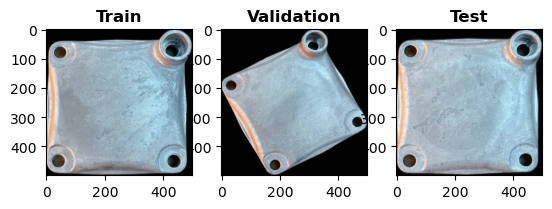

In [6]:
# Check data image plotting run in CPU environment.
import random
import matplotlib.pyplot as plt

img_train = X_train[random.randint(1,X_train.shape[0])].transpose((1,2,0))
img_val = X_val[random.randint(1,X_val.shape[0])].transpose((1,2,0))
img_test = X_test[random.randint(1,X_test.shape[0])].transpose((1,2,0))

plt.figure()
plt.subplot(1,3,1)
plt.imshow(img_train)
plt.title('Train', fontweight ="bold") 
plt.subplot(1,3,2)
plt.imshow(img_val)
plt.title('Validation', fontweight ="bold") 
plt.subplot(1,3,3)
plt.imshow(img_test)
plt.title('Test', fontweight ="bold") 
plt.show()